In [1]:
Threads.nthreads()

4

In [2]:
using Pkg
Pkg.activate("..")
using StaticArrays
using Eliashberg
using CairoMakie
using GLMakie
println("Eliashberg loaded successfully!")

  Activating 

Eliashberg loaded successfully!


project at `~/Developer/theory/Eliashberg`


### Define a 1D Tight-Binding model (Perfect nesting condition)


In [3]:
t = 1.0
tp = 0.0
mu = 0.0
tb_model = TightBinding{1}(t, tp, mu)
kgrid = generate_1d_kgrid(1000)
Nq = 100
# 产生一个均匀的 q 网格用于探测 BZ 内的不稳定点
qgrid = generate_1d_kgrid(Nq)

T_val = 0.1

0.1

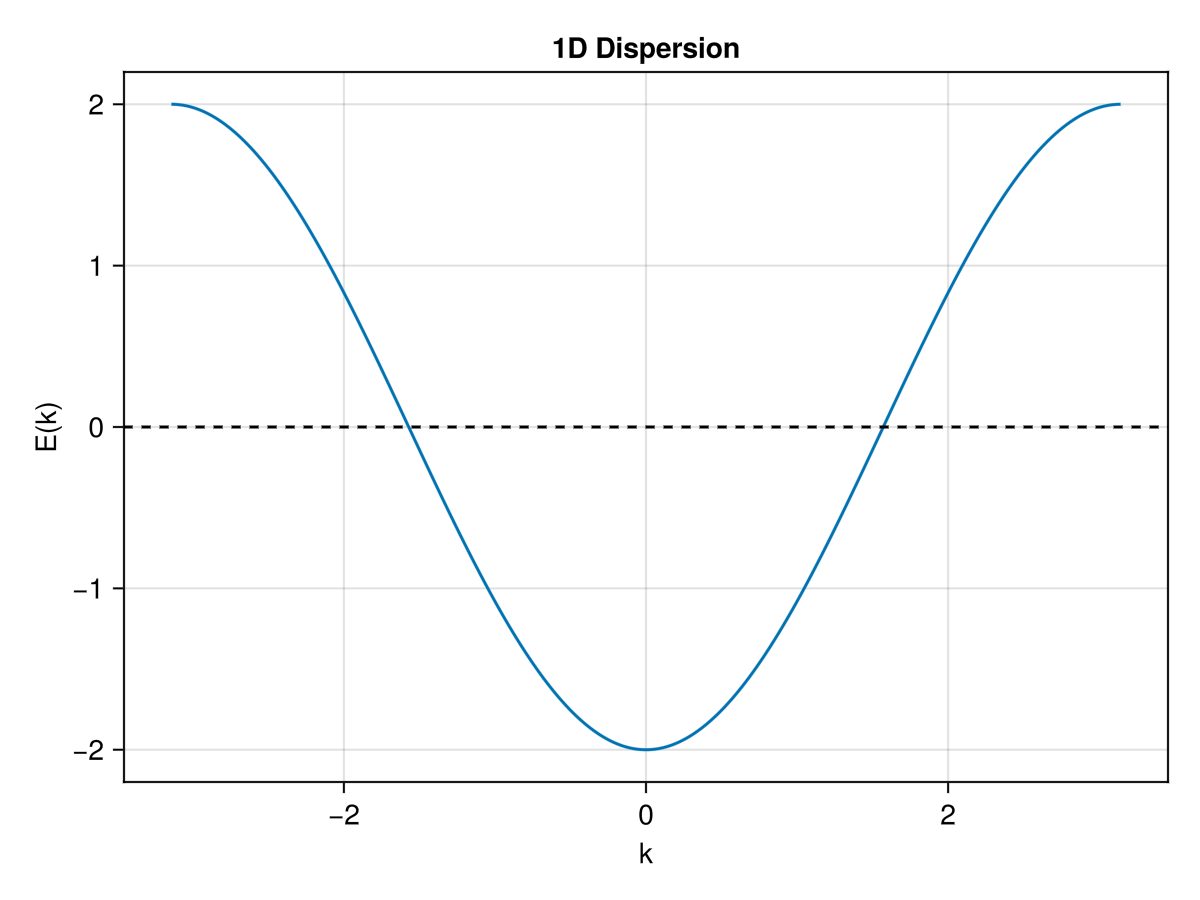

In [4]:
f = visualize_dispersion(tb_model, kgrid)
save("tb_1d_eband.png", f)
f

In [7]:
Q = SVector{1, Float64}(pi)
sc = SuperconductingPairing(:d_wave)
V_bare = 2.0
action = EffectiveAction(tb_model, sc, kgrid, V_bare)

phi_values = range(0.0, 1.5, length=30)
T_val = 0.1


F_exact_vals = evaluate(action, phi_values, ExactTrLn(); T=T_val)
F_RPA_vals   = evaluate(action, phi_values, RPA(); T=T_val)
# Solve for the optimal ground state configuration dynamically using Optim
phi_gs_exact = solve_ground_state(action, ExactTrLn(); phi_guess=0.5)
phi_gs_rpa = solve_ground_state(action, RPA(); phi_guess=0.5)

println("Exact Ground state order parameter ϕ = ", phi_gs_exact)
println("RPA Ground state order parameter ϕ = ", phi_gs_rpa)

LoadError: MethodError: no method matching MeanFieldDispersion(::TightBinding{1}, ::SuperconductingPairing, ::Float64)
The type `MeanFieldDispersion` exists, but no method is defined for this combination of argument types when trying to construct it.

[0mClosest candidates are:
[0m  MeanFieldDispersion(::M, [91m::ChargeDensityWave{D}[39m, ::Real) where {D, M<:ElectronicDispersion}
[0m[90m   @[39m [35mEliashberg[39m [90m~/Developer/theory/Eliashberg/src/[39m[90m[4mdispersions.jl:48[24m[39m


In [5]:
gapped_tb = MeanFieldDispersion(tb_model, cdw, phi_gs_exact)

MeanFieldDispersion{1, TightBinding{1}, ChargeDensityWave{1}}(TightBinding{1}(1.0, 0.0, 0.0), ChargeDensityWave{1}([3.141592653589793]), 0.33990032128636366)

In [6]:
f = visualize_dispersion(gapped_tb, kgrid)
save("renormalized_1d_eband.png", f)


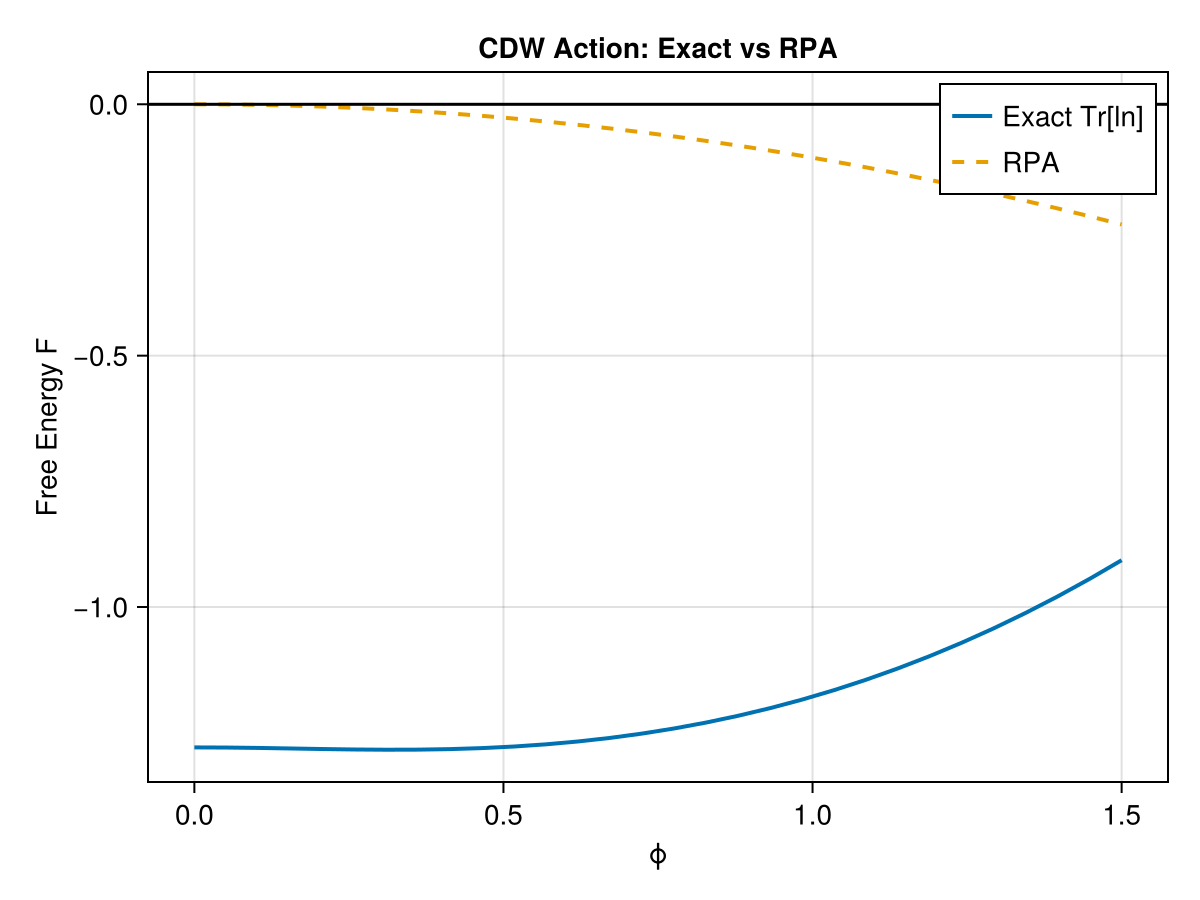

In [7]:
CairoMakie.activate!()
fig_action = Figure()
ax = Axis(fig_action[1, 1], xlabel = "ϕ", ylabel = "Free Energy F", title="CDW Action: Exact vs RPA")
lines!(ax, phi_values, F_exact_vals, label="Exact Tr[ln]", linewidth=2)
lines!(ax, phi_values, F_RPA_vals, label="RPA", linestyle=:dash, linewidth=2)
hlines!(ax, [0.0], color=:black)
axislegend(ax)
save("tb_1d_effective_pot.png", fig_action)
fig_action

[ Info: Scanning instability landscape over 100 q-points...


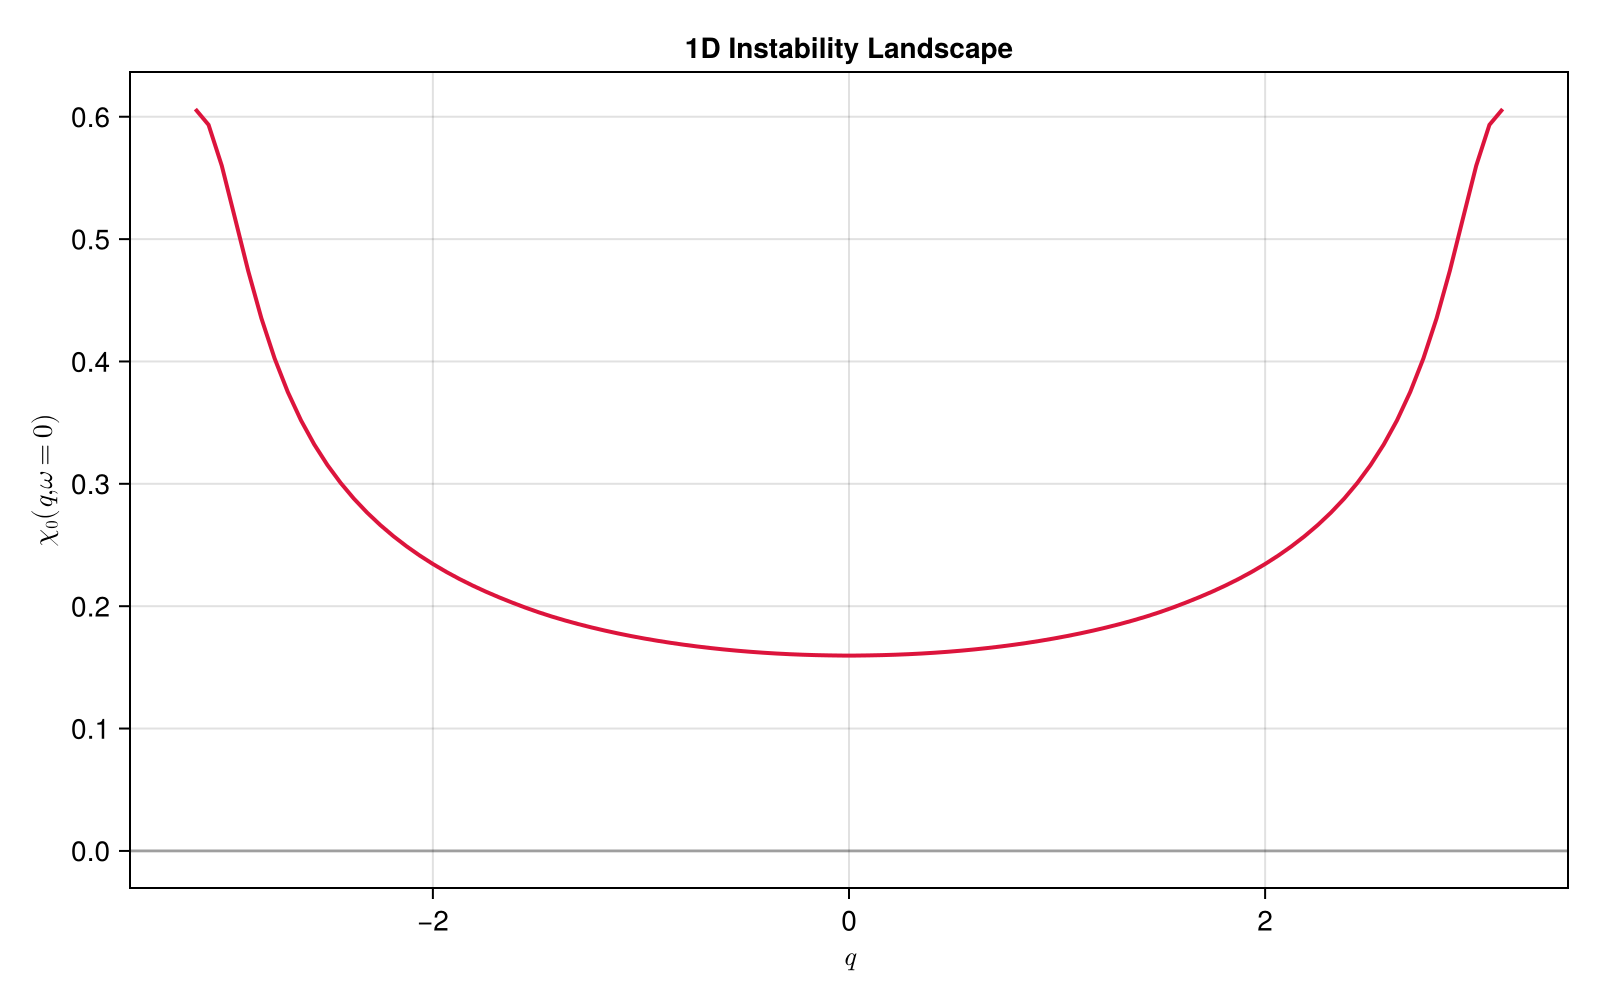

In [ ]:
landscape_data = scan_instability_landscape(tb_model, kgrid, qgrid; T=T_val)
landscape_matrix = reshape(landscape_data, Nq)
fig_ls = visualize_landscape(Val(1), qgrid, landscape_matrix)
save("tb_1d_rpa_static.png", fig_ls)
display(fig_ls)

[ Info: Scanning spectral function over 501 q-points and 1000 frequencies...


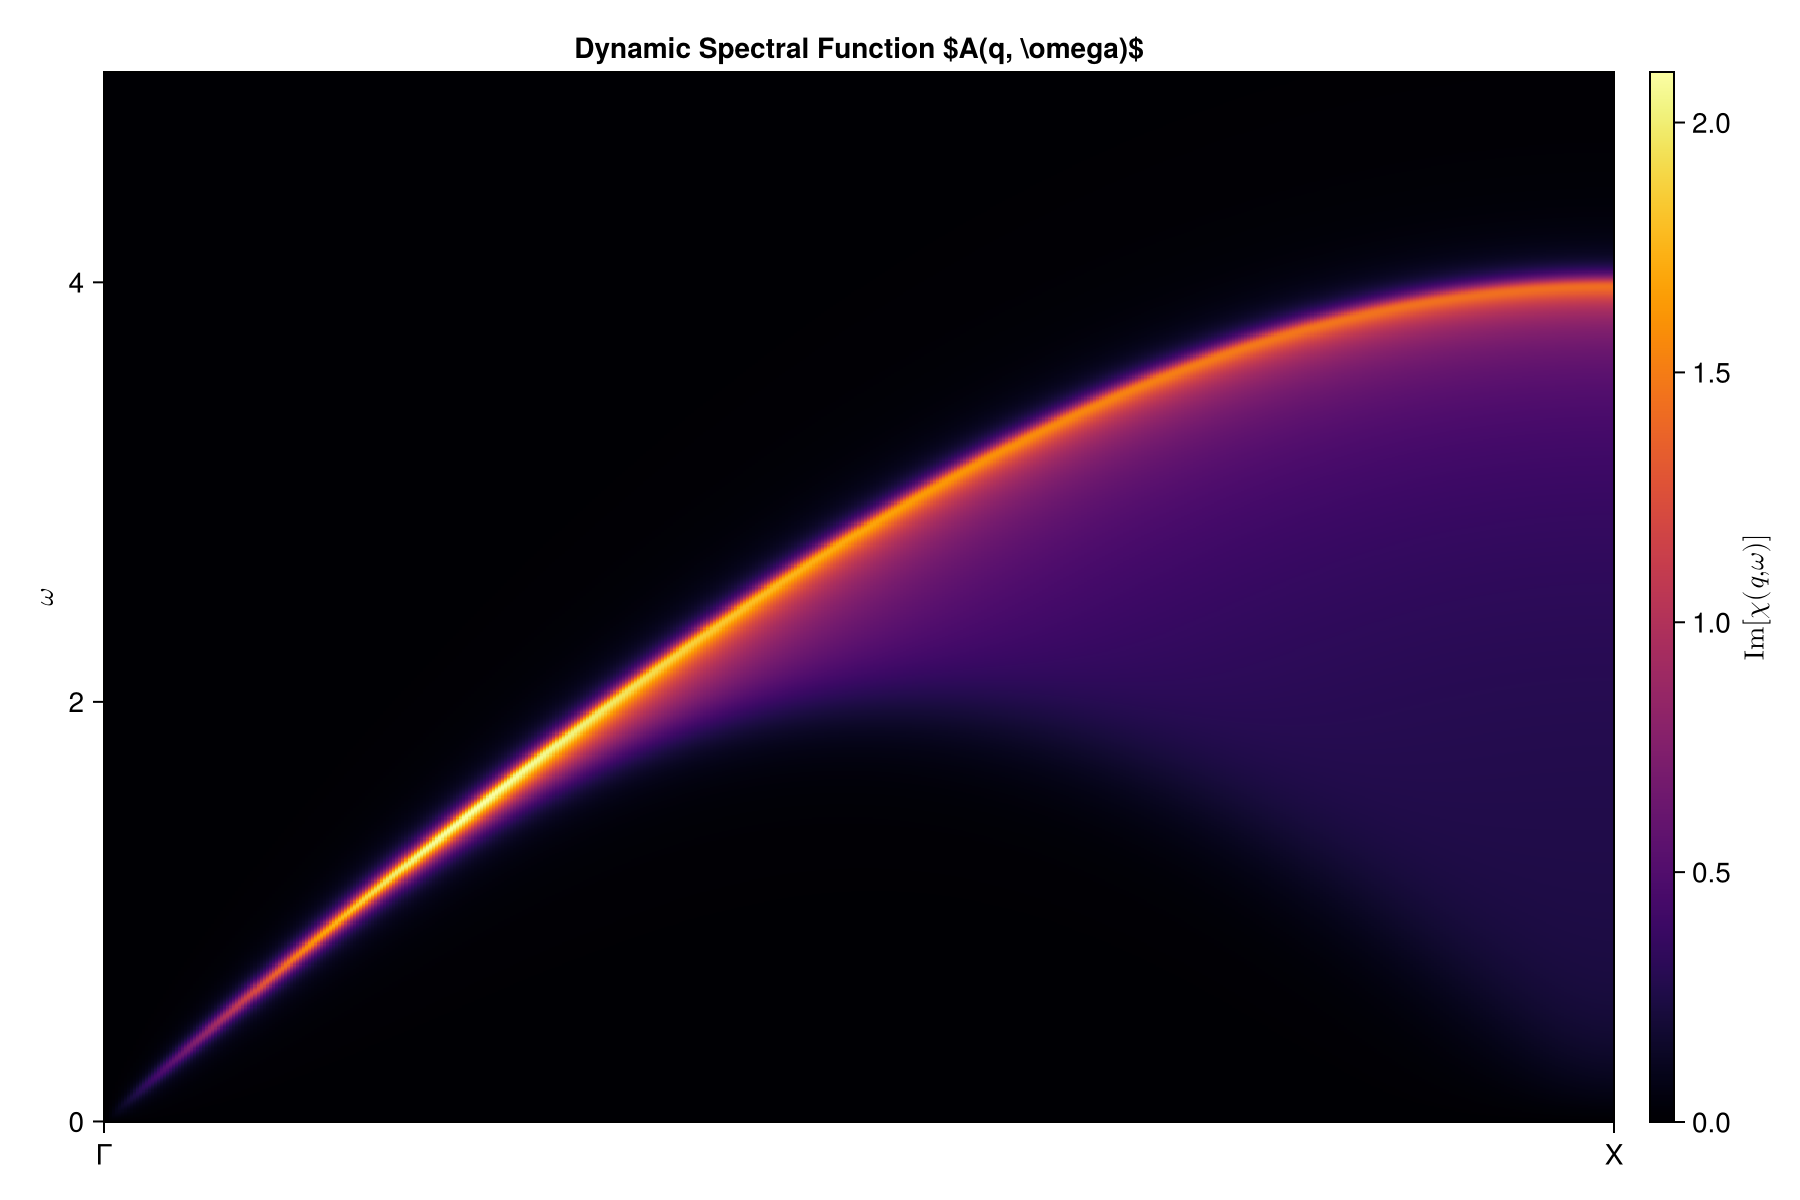

CairoMakie.Screen{IMAGE}


In [9]:
# 1. 定义高对称路径 (例如：Γ -> X -> M -> Γ)
nodes = [
    SVector{1, Float64}(0.0),    # Γ
    SVector{1, Float64}(pi),     # X
]
labels = ["Γ", "X"]
qpath = generate_kpath(nodes, labels; n_pts_per_segment=500)
# 2. 定义能量/频率范围 ω
omegas = range(0.0, 5, length=1000)
# 3. 执行动态谱扫描
# A(q, ω) 矩阵的大小为 (length(q_path), length(omegas))
spectral_matrix = scan_spectral_function(tb_model, kgrid, qpath, omegas; T=T_val, η=0.04)
# 4. 可视化扫描结果
# 该函数会自动根据 q_path 的节点添加高对称点标签和垂直分割线
fig_spectral = visualize_spectral_function(qpath, omegas, spectral_matrix)
save("tb_1d_rpa_spectral.png", fig_spectral)
display(fig_spectral)


### Define a 2D Tight-Binding model (Perfect nesting condition)


In [3]:
t = 1.0
tp = 0.0
mu = 0.0
tb_model = TightBinding{2}(t, tp, mu)
kgrid = generate_2d_kgrid(100, 100) 

# 定义 3D 简立方的高对称点
nodes = [
    SVector{2, Float64}(0, 0),    # Γ
    SVector{2, Float64}(pi, 0),   # X
    SVector{2, Float64}(pi, pi),  # M
    SVector{2, Float64}(0, 0)     # Γ
]
labels = ["Γ", "X", "M", "Γ"]
path = generate_kpath(nodes, labels; n_pts_per_segment=50)

# --- B. 可视化静态景观 (Landscape) ---
Nq = 100
# 产生一个均匀的 q 网格用于探测 BZ 内的不稳定点
qgrid = generate_2d_kgrid(Nq, Nq)
smearing = FermiDiracSmearing(0.01) # T = 0.01

FermiDiracSmearing(0.01)

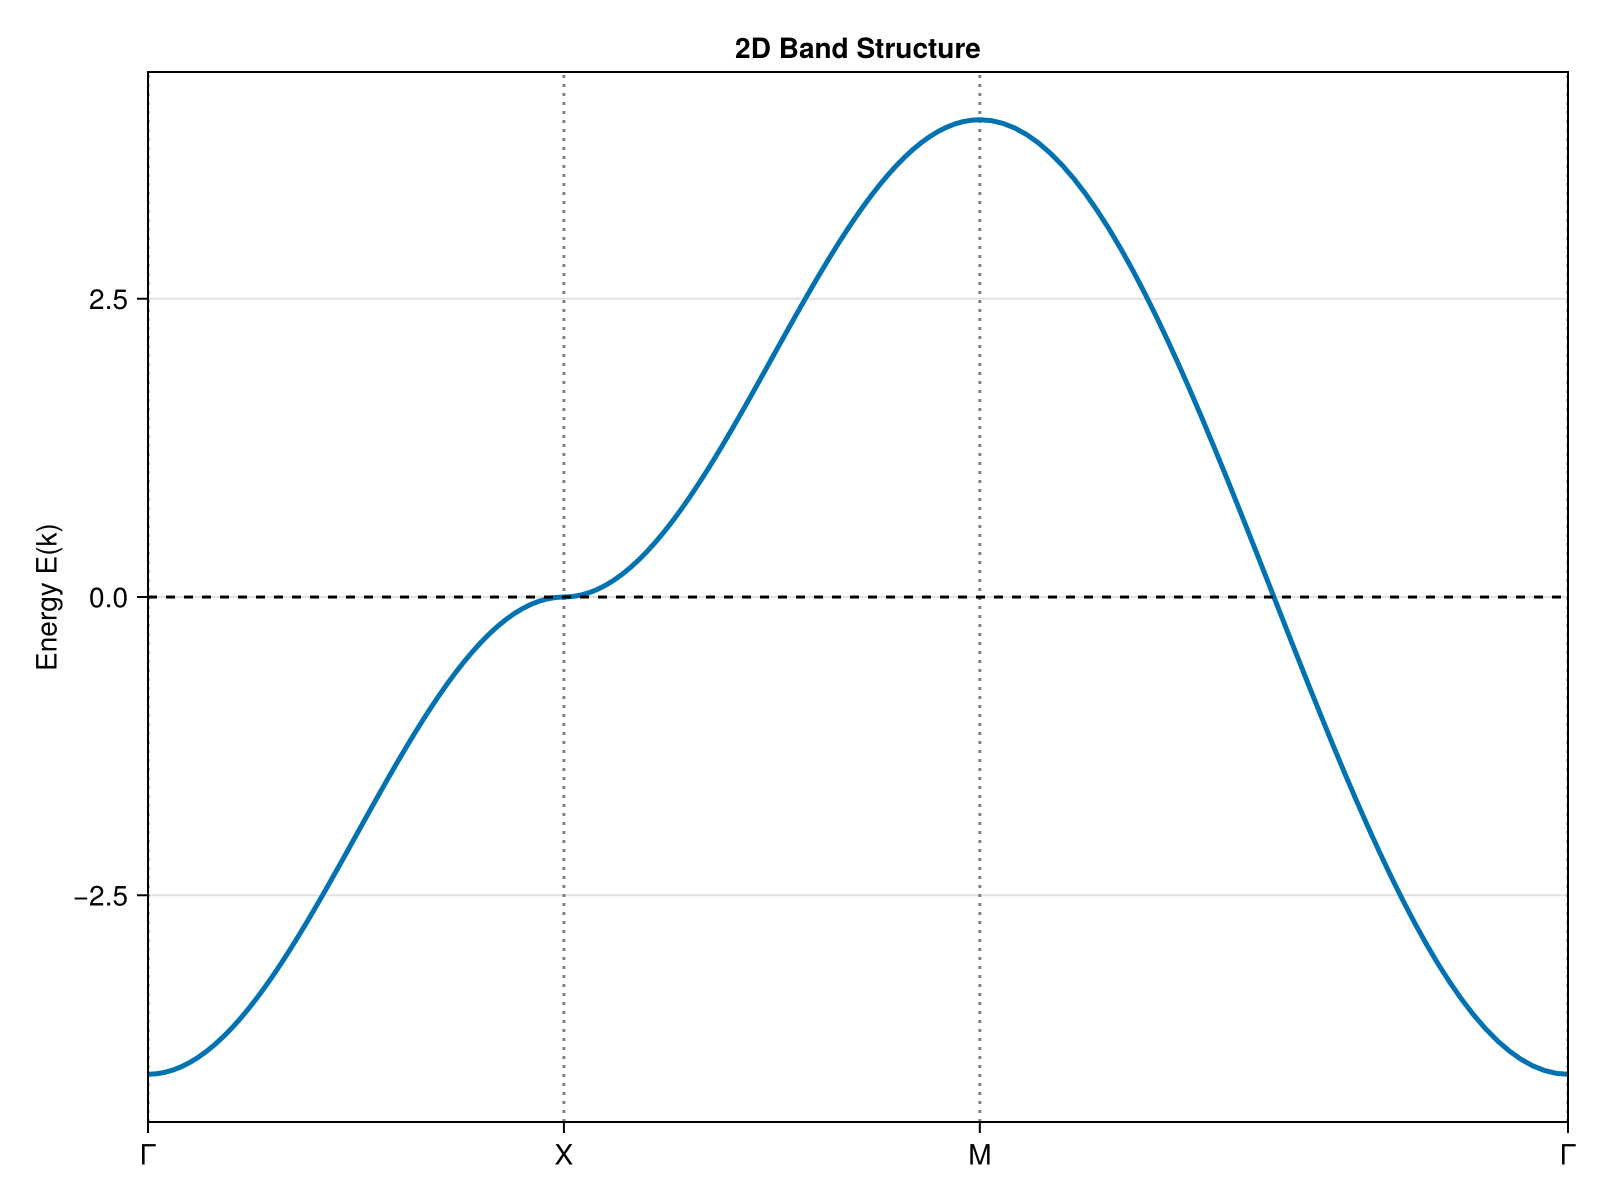

In [4]:
CairoMakie.activate!()
f = visualize_dispersion(tb_model, path)
save("tb_2d_eband_GXMG.png", f)
f

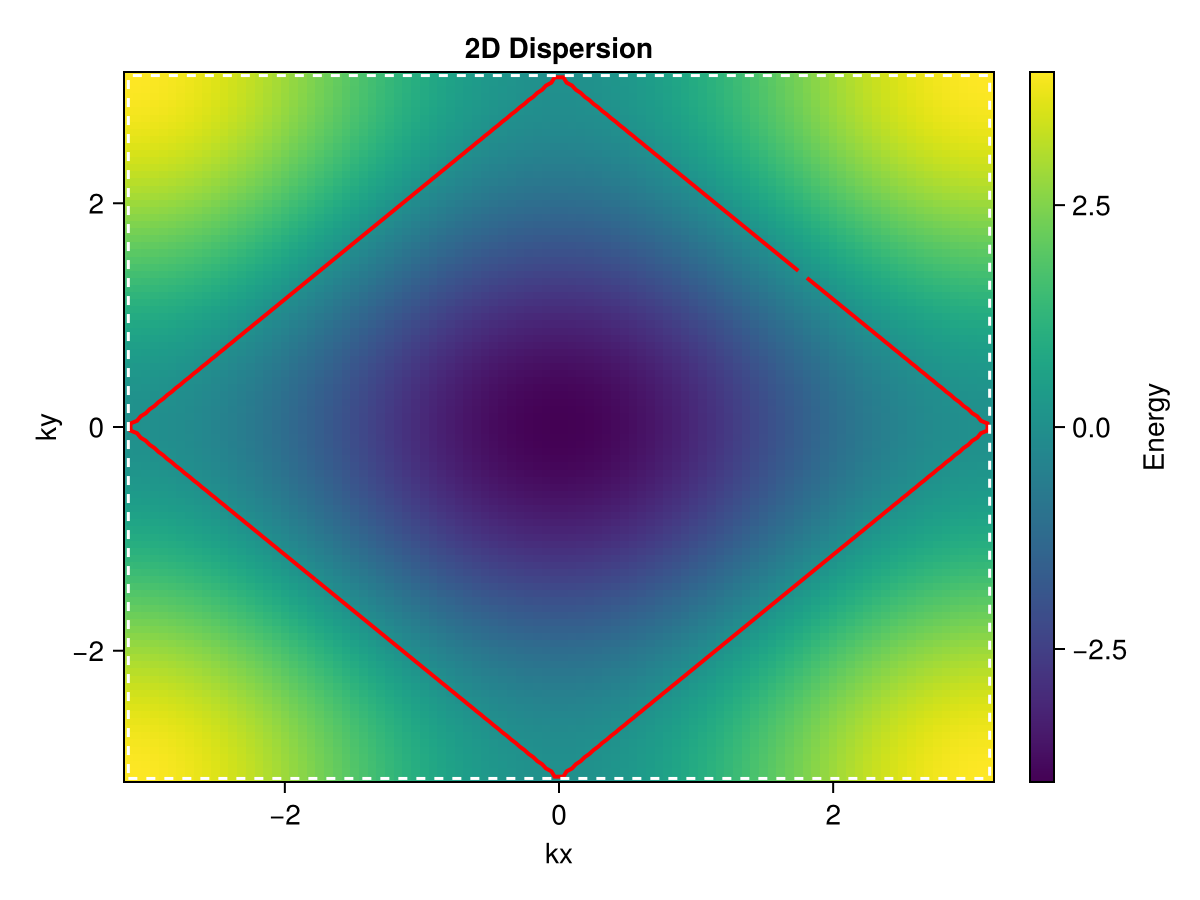

In [18]:
f = visualize_dispersion(tb_model, kgrid)
save("tb_2d_eband.png", f)
f

In [5]:
Q = SVector{2, Float64}(pi, pi)
cdw = ChargeDensityWave(Q)
V_bare = 2.0
action = EffectiveAction(tb_model, cdw, kgrid, V_bare)

phi_values = range(0.0, 1.5, length=30)
T_val = 0.1

F_exact_vals = evaluate(action, phi_values, ExactTrLn(); T=T_val)
F_RPA_vals   = evaluate(action, phi_values, RPA(); T=T_val)

# Solve for the optimal ground state configuration dynamically using Optim
phi_gs_exact = solve_ground_state(action, ExactTrLn(); phi_guess=0.5)
phi_gs_rpa = solve_ground_state(action, RPA(); phi_guess=0.5)

println("Exact Ground state order parameter ϕ = ", phi_gs_exact)
println("RPA Ground state order parameter ϕ = ", phi_gs_rpa)

Exact Ground state order parameter ϕ = 0.3750449430457662
RPA Ground state order parameter ϕ = 2.361519249611284e34


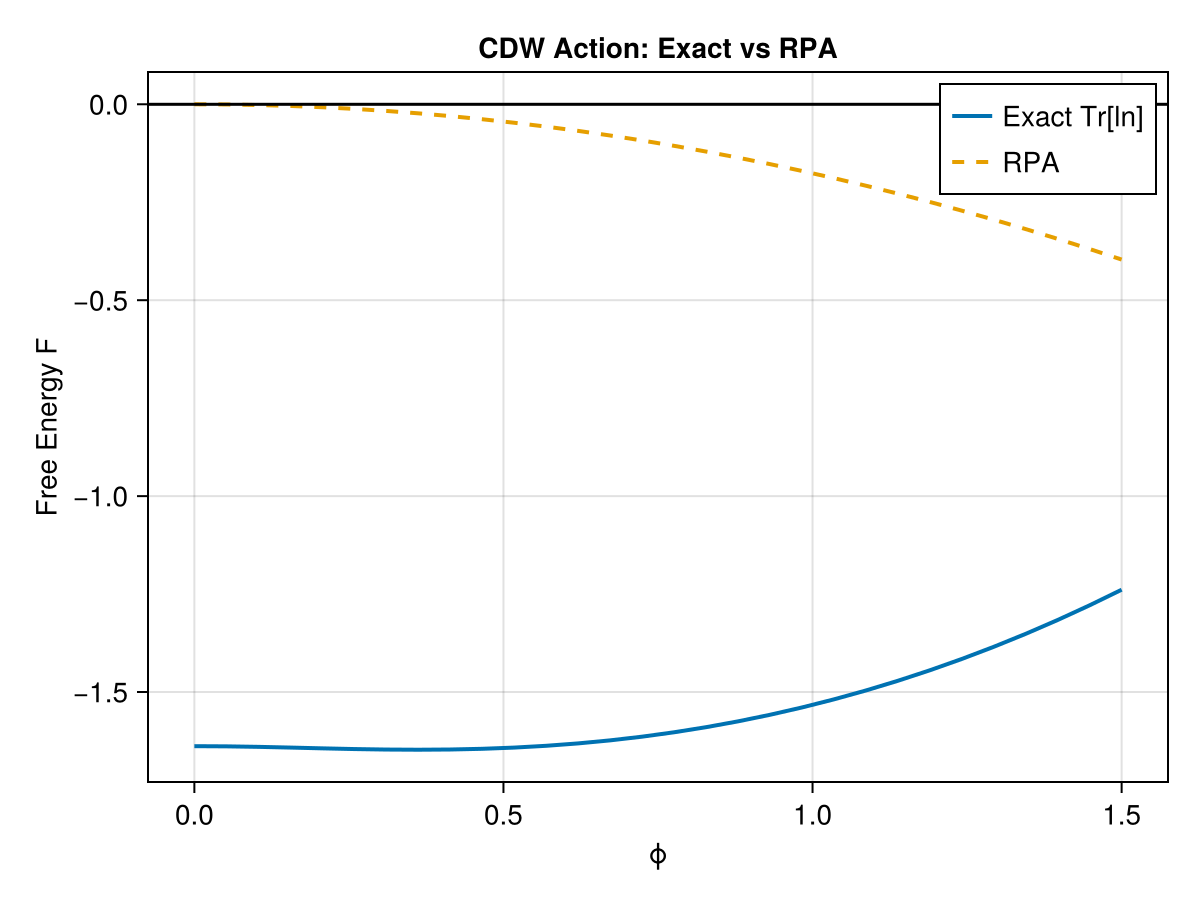

In [6]:
fig_action = Figure()
ax = Axis(fig_action[1, 1], xlabel = "ϕ", ylabel = "Free Energy F", title="CDW Action: Exact vs RPA")
lines!(ax, phi_values, F_exact_vals, label="Exact Tr[ln]", linewidth=2)
lines!(ax, phi_values, F_RPA_vals, label="RPA", linestyle=:dash, linewidth=2)
hlines!(ax, [0.0], color=:black)
axislegend(ax)
save("tb_2d_effective_pot.png", fig_action)

fig_action

[ Info: Scanning instability landscape over 10000 q-points...


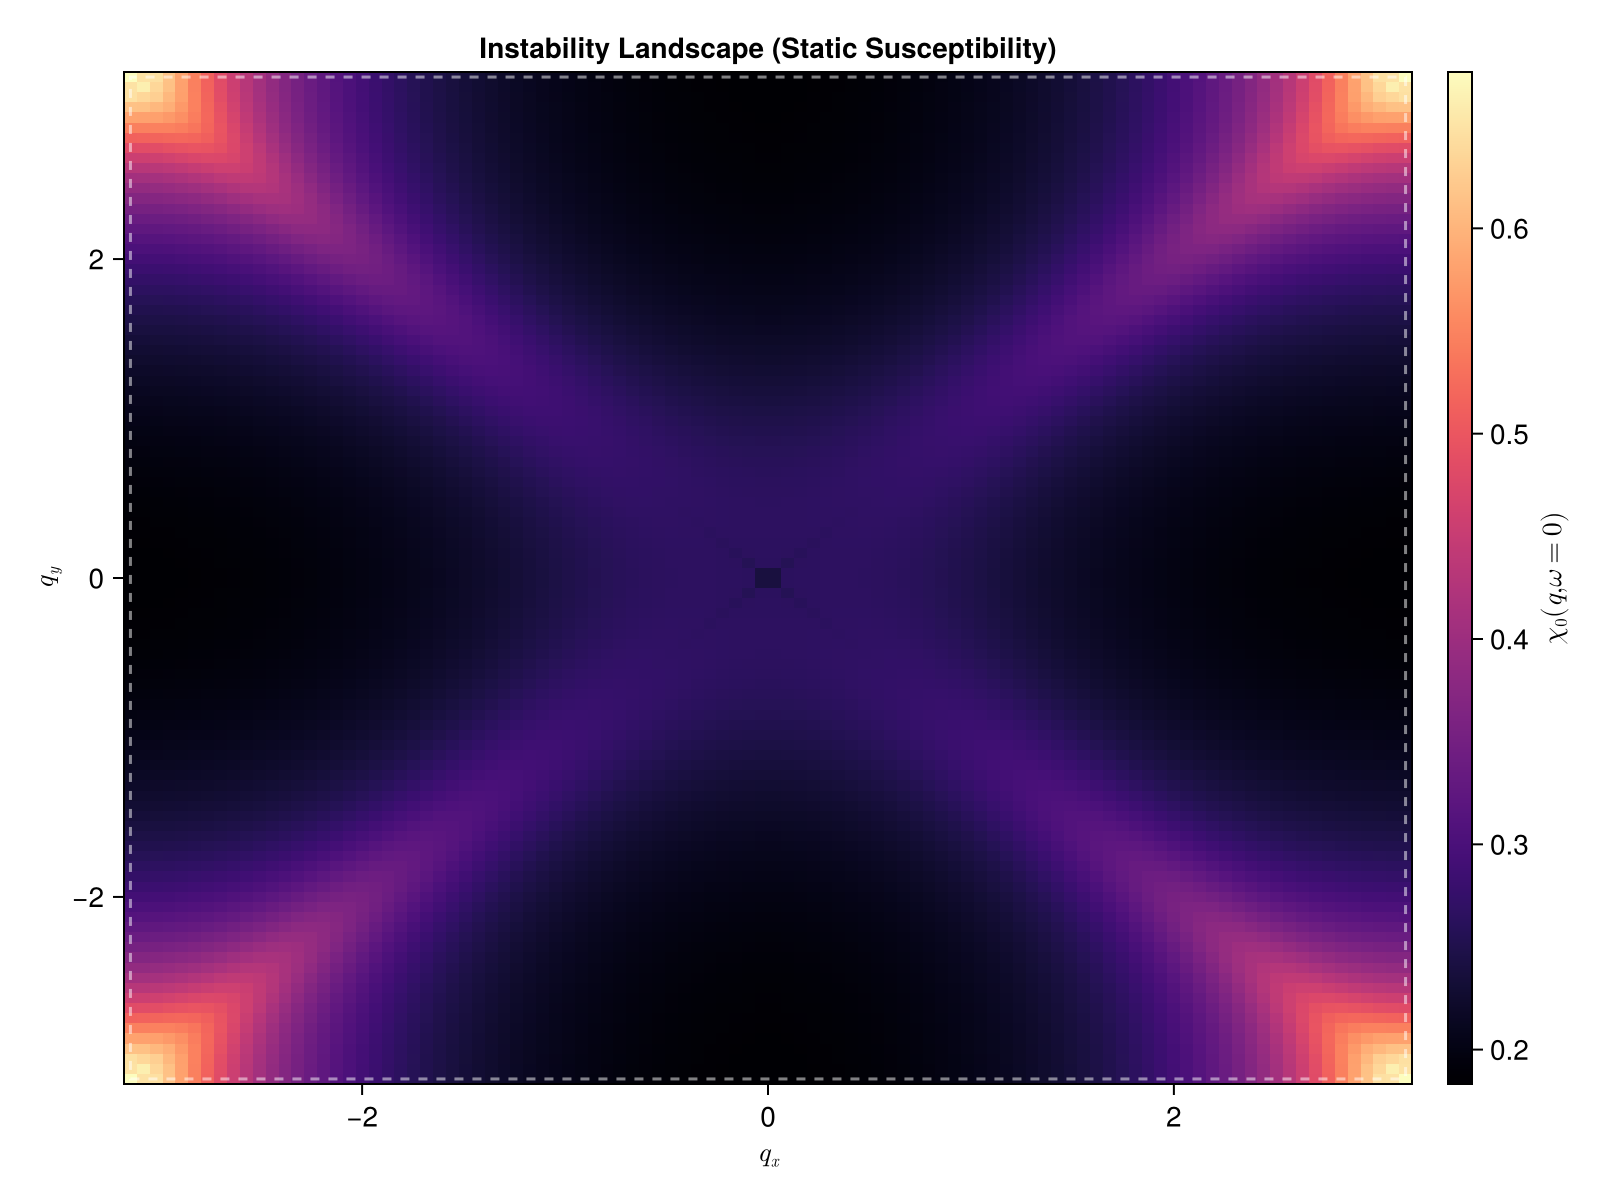

In [7]:
landscape_data = scan_instability_landscape(tb_model, kgrid, qgrid; T=T_val)
landscape_matrix = reshape(landscape_data, Nq, Nq)
fig_ls = visualize_landscape(Val(2), qgrid, landscape_matrix)

[ Info: Scanning spectral function over 5001 q-points and 2000 frequencies with extreme optimization...


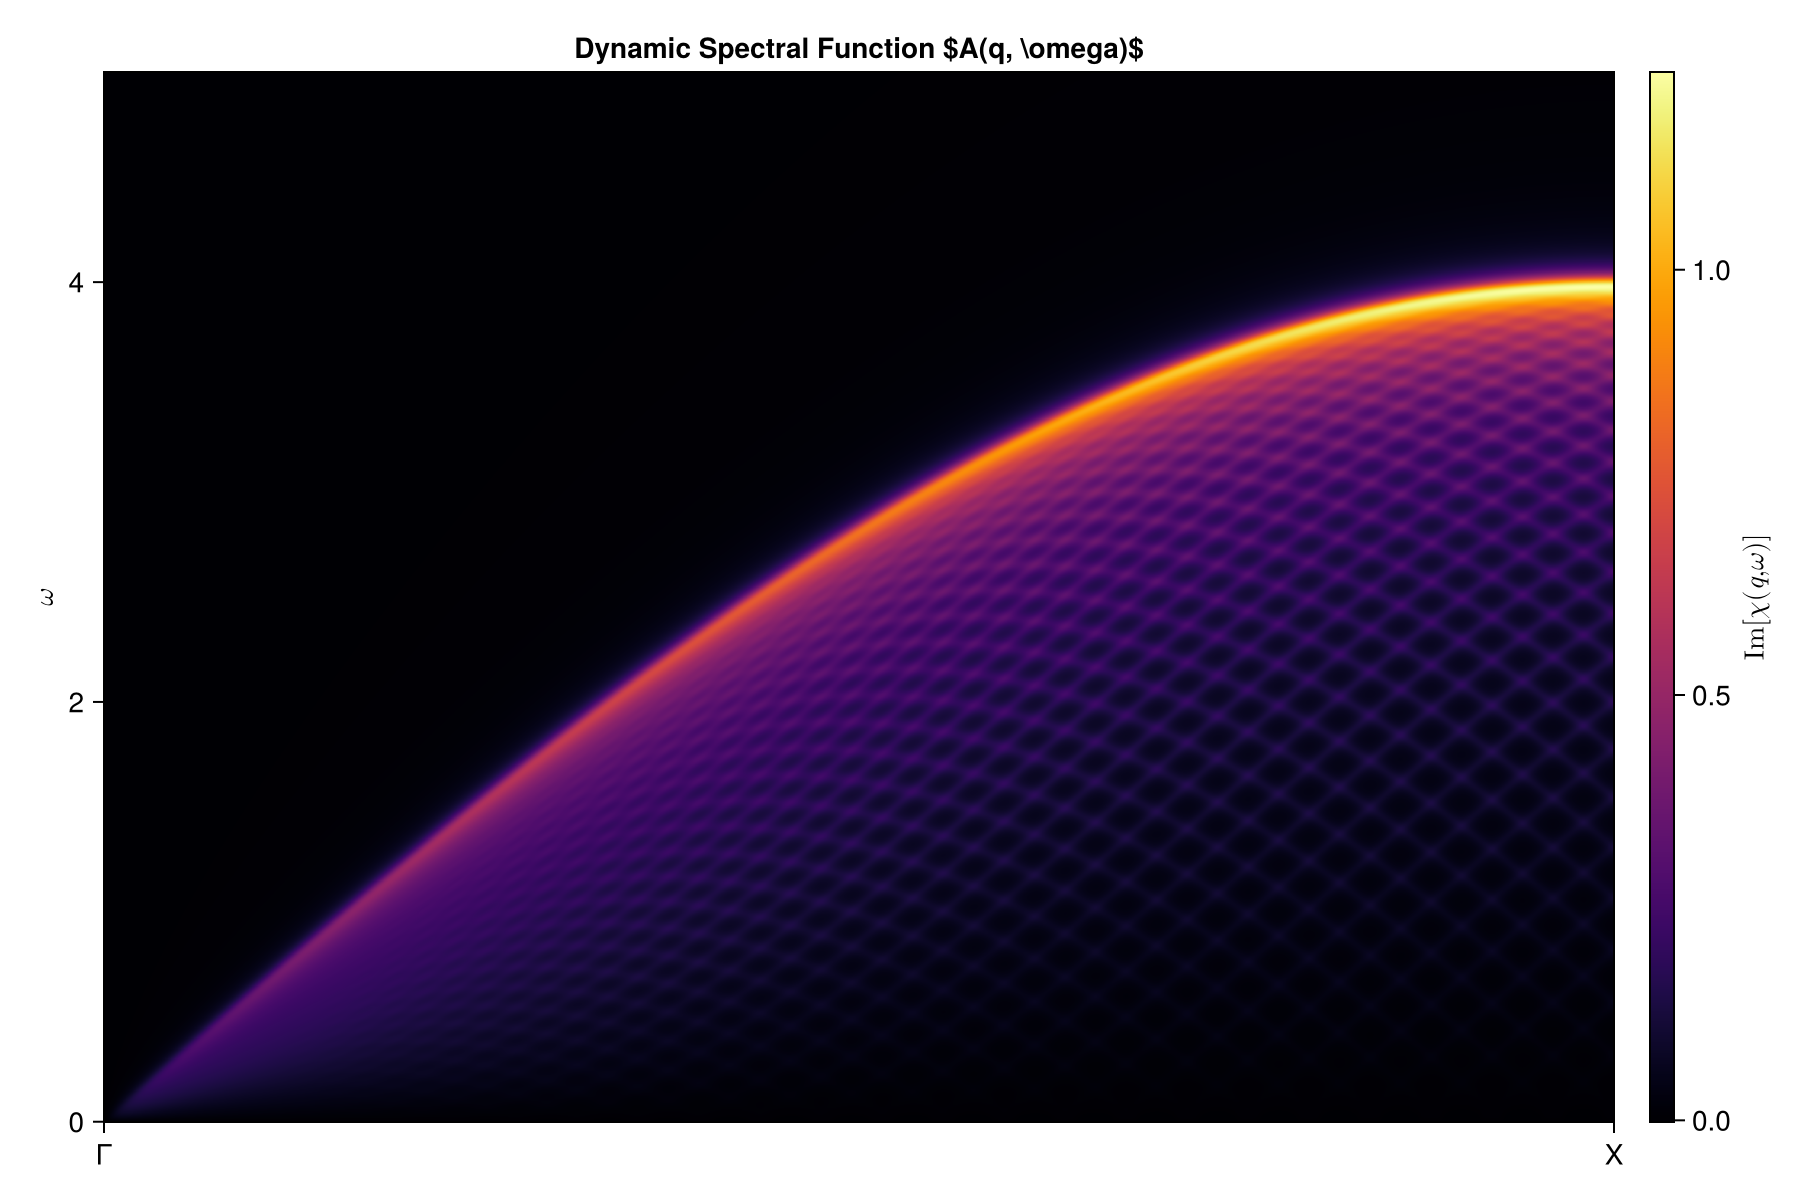

CairoMakie.Screen{IMAGE}


In [11]:
# 1. 定义高对称路径 (例如：Γ -> X -> M -> Γ)
# 定义 3D 简立方的高对称点
nodes = [
    SVector{2, Float64}(0, 0),    # Γ
    SVector{2, Float64}(pi, 0),   # X
    # SVector{2, Float64}(pi, pi),  # M
    # SVector{2, Float64}(0, 0)     # Γ
]
labels = ["Γ", "X"]
qpath = generate_kpath(nodes, labels; n_pts_per_segment=5000)

# 2. 定义能量/频率范围 ω
omegas = range(0.0, 5, length=2000)
# 3. 执行动态谱扫描
# A(q, ω) 矩阵的大小为 (length(q_path), length(omegas))
spectral_matrix = scan_spectral_function(tb_model, kgrid, qpath, omegas; T=T_val, η=0.04)
# 4. 可视化扫描结果
# 该函数会自动根据 q_path 的节点添加高对称点标签和垂直分割线
fig_spectral = visualize_spectral_function(qpath, omegas, spectral_matrix)
display(fig_spectral)

### Define a 3D Tight-Binding model (Perfect nesting condition)


In [3]:
t = 1.0
tp = 0.0
mu = 0.0
tb_model = TightBinding{3}(t, tp, mu)
kgrid = generate_3d_kgrid(50, 50, 50)
smearing = FermiDiracSmearing(0.01) # T = 0.01

# 定义 3D 简立方的高对称点
Γ = SVector(0.0, 0.0, 0.0)
X = SVector(π, 0.0, 0.0)
M = SVector(π, π, 0.0)
R = SVector(π, π, π)

# 生成 KPath
# 路径：Γ -> X -> M -> Γ -> R
nodes = [Γ, X, M, Γ, R]
labels = ["Γ", "X", "M", "Γ", "R"]
path = generate_kpath(nodes, labels; n_pts_per_segment=50)



KPath{3}(SVector{3, Float64}[[0.0, 0.0, 0.0], [0.06283185307179587, 0.0, 0.0], [0.12566370614359174, 0.0, 0.0], [0.18849555921538758, 0.0, 0.0], [0.25132741228718347, 0.0, 0.0], [0.3141592653589793, 0.0, 0.0], [0.37699111843077515, 0.0, 0.0], [0.4398229715025711, 0.0, 0.0], [0.5026548245743669, 0.0, 0.0], [0.5654866776461628, 0.0, 0.0]  …  [2.57610597594363, 2.57610597594363, 2.57610597594363], [2.638937829015426, 2.638937829015426, 2.638937829015426], [2.701769682087222, 2.701769682087222, 2.701769682087222], [2.764601535159018, 2.764601535159018, 2.764601535159018], [2.827433388230814, 2.827433388230814, 2.827433388230814], [2.8902652413026098, 2.8902652413026098, 2.8902652413026098], [2.9530970943744053, 2.9530970943744053, 2.9530970943744053], [3.015928947446201, 3.015928947446201, 3.015928947446201], [3.078760800517997, 3.078760800517997, 3.078760800517997], [3.141592653589793, 3.141592653589793, 3.141592653589793]], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 

In [4]:
CairoMakie.activate!()
f = visualize_dispersion(tb_model, path)
save("tb_3d_eband_GXMGR.png", f)

In [5]:
GLMakie.activate!()
f = visualize_dispersion(tb_model, kgrid; E_Fermi=0.0)
# save("tb_3d_eband_fs.png", f)

Calculating energies on a dense 100 x 100 x 100 mesh for 3D visualization...


LoadError: Invalid attribute [31m[1mshading[22m[39m for plot type [34m[1mContour{Tuple{Makie.EndPoints{Float64}, Makie.EndPoints{Float64}, Makie.EndPoints{Float64}, Array{Float32, 3}}}[22m[39m.

The available plot attributes for Contour{Tuple{Makie.EndPoints{Float64}, Makie.EndPoints{Float64}, Makie.EndPoints{Float64}, Array{Float32, 3}}} are:

alpha        enable_depth     isorange        levels       nan_color     
clip_planes  fxaa             joinstyle       linecap      overdraw      
color        highclip         labelcolor      linestyle    space         
colormap     inspectable      labelfont       linewidth    ssao          
colorrange   inspector_clear  labelformatter  lowclip      transformation
colorscale   inspector_hover  labels          miter_limit  transparency  
depth_shift  inspector_label  labelsize       model        visible       

